### Imports

In [5]:
import json
import warnings
from pathlib import Path

import torch
from matplotlib import pyplot as plt

from src.datasets.audio_dataset import AudioDataset
from src.engine import benchmark_cnn, benchmark_snn, get_split_dataloaders
from src.models.cnn import CNN
from src.models.snn import SNN
from src.preprocessing import get_cnn_pipeline, get_snn_pipeline
from src.utils import plot_accuracy_comparison, plot_energy_comparison

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [6]:
CNN_NAME: str = CNN.NAME
SNN_NAME: str = SNN.NAME

INPUT_DIR = Path('../../data/audio-mnist')
CNN_MODEL_PATH = Path(f'../../models/{CNN_NAME}.pth')
SNN_MODEL_PATH = Path(f'../../models/{SNN_NAME}.pth')
SNN_HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{SNN_NAME}.json')

### Device

In [7]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Comparison

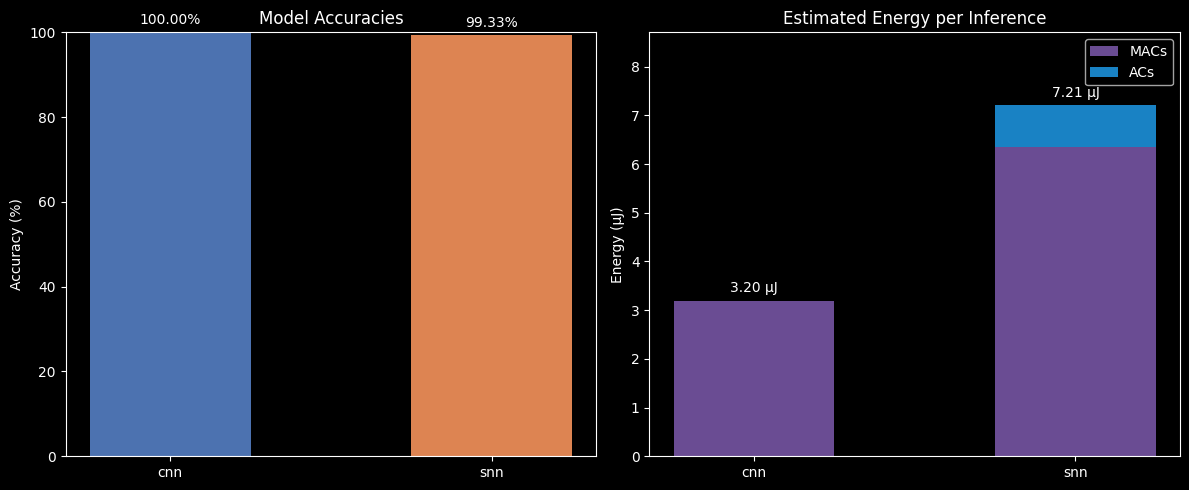

In [8]:
if __name__ == '__main__':
    cnn_dataset = AudioDataset(INPUT_DIR, get_cnn_pipeline())
    snn_dataset = AudioDataset(INPUT_DIR, get_snn_pipeline())

    # Use the same seed for split so that models are tested on exact same things
    _, _, cnn_test_dataloader = get_split_dataloaders(cnn_dataset)
    _, _, snn_test_dataloader = get_split_dataloaders(snn_dataset)

    _, sample_cnn_labels = next(iter(cnn_test_dataloader))
    _, sample_snn_labels = next(iter(snn_test_dataloader))
    assert torch.equal(sample_cnn_labels, sample_snn_labels) # Should fail here immediately, otherwise not a fair test

    # Load CNN
    cnn = CNN().to(device)
    cnn.load_state_dict(torch.load(CNN_MODEL_PATH))

    # Load SNN
    snn_hyperparameters = json.load(open(SNN_HYPERPARAMETERS_PATH, 'r'))[1]['params']
    snn = SNN(
        beta_init=snn_hyperparameters['beta_init'],
        slope=snn_hyperparameters['slope'],
        timesteps=snn_hyperparameters['timesteps']
    ).to(device)
    snn.load_state_dict(torch.load(SNN_MODEL_PATH))

    cnn_acc, cnn_macs = benchmark_cnn(device, cnn, cnn_test_dataloader, leave=False)
    snn_acc, snn_acs, snn_macs = benchmark_snn(device, snn, snn_test_dataloader, direct_encoded=True, leave=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    plot_accuracy_comparison(ax1, CNN_NAME, cnn_acc, SNN_NAME, snn_acc)
    plot_energy_comparison(ax2, CNN_NAME, cnn_macs, 0, SNN_NAME, snn_macs, snn_acs)
    plt.tight_layout()
    plt.show()